In [3]:
   import random, shutil
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import albumentations as A
from sklearn.model_selection import train_test_split

# ---------- settings ----------
INPUT_ROOT = Path("/kaggle/input/datasets/bhanukachamindu/aloe-colour")
OUT_DIR = Path("/kaggle/working/colour_dataset")
IMG_SIZE = 224                       # every image is resized to IMG_SIZE x IMG_SIZE
TARGET_MIN, TARGET_MAX = 1200, 1300  # train images per class
MAX_AUG_FACTOR = 6                   # a class never gets more than 6x its real train images
VAL_FRAC, TEST_FRAC = 0.15, 0.15
SEED = 42
MERGE = {}                           # nothing to merge
EXPECTED_CLASSES = 3                 # brown, green, yellow
RUN_GROUP_SPLIT = False              # True = leak-safe split in Cell 2b (slower)
# ------------------------------

random.seed(SEED)
np.random.seed(SEED)

IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}

def is_img(f):
    return f.is_file() and f.suffix.lower() in IMG_EXT

def find_class_root(root):
    """Go down through wrapper folders until we reach the folder that holds the class folders."""
    cur = Path(root)
    while True:
        subdirs = sorted(p for p in cur.iterdir() if p.is_dir())
        if len(subdirs) == 1 and not any(is_img(f) for f in cur.iterdir()):
            cur = subdirs[0]
        else:
            return cur

DATA_DIR = find_class_root(INPUT_ROOT)
top = sorted(p for p in DATA_DIR.iterdir() if p.is_dir())

if top and all(p.name.strip().lower() in SPLIT_NAMES for p in top):
    class_dirs = sorted(c for s in top for c in s.iterdir() if c.is_dir())
    print("Dataset is already split into", [p.name for p in top],
          "-> pooling all images and re-splitting")
else:
    class_dirs = top

print("Using folder:", DATA_DIR, "\n")
for c in class_dirs:
    n = sum(1 for f in c.rglob("*") if is_img(f))
    print(f"  {c.parent.name}/{c.name:28s} {n}")

Using folder: /kaggle/input/datasets/bhanukachamindu/aloe-colour/Aloe_Vera_Dataset_Colour 

  Aloe_Vera_Dataset_Colour/Brown                        335
  Aloe_Vera_Dataset_Colour/Yellow                       3849
  Aloe_Vera_Dataset_Colour/green                        1923


In [4]:
def class_name(folder_name):
    key = folder_name.strip().lower().replace("_", " ")
    return MERGE.get(key, key.replace(" ", "_"))

rows = []
for c in class_dirs:
    for f in c.rglob("*"):
        if is_img(f):
            rows.append({"path": str(f), "source_folder": c.name, "label": class_name(c.name)})

df = pd.DataFrame(rows)
if df["label"].nunique() < 2:
    raise ValueError(f"Only {df['label'].nunique()} class found: {df['label'].unique()}. "
                     "INPUT_ROOT is pointing at the wrong folder - check the Cell 1 printout.")

if df["label"].nunique() != EXPECTED_CLASSES:
    print(f"WARNING: expected {EXPECTED_CLASSES} classes but found {df['label'].nunique()}: {sorted(df['label'].unique())}\n")

print("Original counts:")
print(df["label"].value_counts(), "\n")

train_df, temp_df = train_test_split(
    df, test_size=VAL_FRAC + TEST_FRAC, stratify=df["label"], random_state=SEED)
val_df, test_df = train_test_split(
    temp_df, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
    stratify=temp_df["label"], random_state=SEED)

print(f"train {len(train_df)} | val {len(val_df)} | test {len(test_df)}")

Original counts:
label
yellow    3849
green     1923
brown      335
Name: count, dtype: int64 

train 4274 | val 916 | test 917


In [5]:
if not RUN_GROUP_SPLIT:
    print("Skipped (RUN_GROUP_SPLIT = False). Using the random split from Cell 2.")
else:
    from sklearn.model_selection import StratifiedGroupKFold
    from scipy.sparse import coo_matrix
    from scipy.sparse.csgraph import connected_components
    import matplotlib.pyplot as plt

    MAX_GROUP = 60      # a set of copies of one leaf is never expected to be bigger than this
    FORCE_T = None      # leave as None; the code picks the similarity threshold itself

    # ---- fingerprint: 256 bits, flip-proof ----
    def dhash256(gray):
        small = cv2.resize(gray, (17, 16), interpolation=cv2.INTER_AREA)
        bits = (small[:, 1:] > small[:, :-1]).flatten()
        return np.packbits(bits).view(">u8").astype(np.uint64)

    def canonical_hash(path):
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        cands = [dhash256(v) for v in (img, img[:, ::-1], img[::-1, :], img[::-1, ::-1])]
        return min(cands, key=lambda a: tuple(a.tolist()))

    print("Fingerprinting images (1-3 minutes)...")
    hashes = [canonical_hash(p) for p in df["path"]]
    df = df[[x is not None for x in hashes]].reset_index(drop=True)
    H = np.stack([x for x in hashes if x is not None])           # N x 4 (uint64)
    N = len(H)

    # ---- find all pairs of similar images (distance in bits, out of 256) ----
    POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)
    MAXT = 30
    pi, pj, pd_ = [], [], []
    for s in range(0, N, 150):
        x = H[s:s + 150, None, :] ^ H[None, :, :]
        d = POP[x.view(np.uint8)].sum(axis=2, dtype=np.int32)
        rr, cc = np.nonzero(d <= MAXT)
        ok = (s + rr) < cc
        pi.append(s + rr[ok]); pj.append(cc[ok]); pd_.append(d[rr[ok], cc[ok]])
    P_i, P_j, P_d = np.concatenate(pi), np.concatenate(pj), np.concatenate(pd_)

    def groups_at(t):
        m = P_d <= t
        g = coo_matrix((np.ones(m.sum()), (P_i[m], P_j[m])), shape=(N, N))
        return connected_components(g, directed=False)[1]

    print("\nSweep: how similar must two images be to count as copies?")
    print(" bits  largest_group  images_in_groups_of_2+")
    best_t = 0
    for t in [0, 2, 4, 6, 8, 12, 16, 20, 24, 30]:
        lab = groups_at(t)
        sz = np.bincount(lab)
        print(f" {t:4d}  {sz.max():13d}  {int(sz[sz > 1].sum()):22d}")
        if sz.max() <= MAX_GROUP:
            best_t = t
    T = FORCE_T if FORCE_T is not None else best_t
    print(f"\nUsing threshold: {T} bits")

    df["group"] = groups_at(T)
    sizes = df.groupby("group").size()

    print("\nImages per class vs. UNIQUE leaves (groups of copies count once):")
    print(pd.DataFrame({"images": df.groupby("label").size(),
                        "unique_leaves": df.groupby("label")["group"].nunique()}))
    print(f"\nlargest group: {sizes.max()} images | groups with 2+ images: {(sizes > 1).sum()}")

    # ---- split by group ----
    sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=SEED)   # 7 folds -> about 14% each
    folds = [f[1] for f in sgkf.split(df, df["label"], groups=df["group"])]
    test_df = df.iloc[folds[0]]
    val_df = df.iloc[folds[1]]
    train_df = df.iloc[np.concatenate(folds[2:])]

    leak = set(train_df["group"]) & (set(val_df["group"]) | set(test_df["group"]))
    leak |= set(val_df["group"]) & set(test_df["group"])
    print(f"\ntrain {len(train_df)} | val {len(val_df)} | test {len(test_df)} | leaves shared between splits: {len(leak)}")
    print(pd.DataFrame({"train": train_df["label"].value_counts(),
                        "val": val_df["label"].value_counts(),
                        "test": test_df["label"].value_counts()}))

    # ---- look at a few groups: each row should be the same leaf ----
    multi = sizes[sizes > 1].index.tolist()
    show = random.sample(multi, min(5, len(multi)))
    fig, axes = plt.subplots(max(len(show), 1), 4, figsize=(10, 2.3 * max(len(show), 1)), squeeze=False)
    for r, g in enumerate(show):
        files = df[df["group"] == g]["path"].tolist()[:4]
        for k in range(4):
            axes[r, k].axis("off")
            if k < len(files):
                axes[r, k].imshow(cv2.cvtColor(cv2.imread(files[k]), cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()

Skipped (RUN_GROUP_SPLIT = False). Using the random split from Cell 2.


In [6]:
shutil.rmtree(OUT_DIR, ignore_errors=True)   # safe to re-run

def load_resized(path):
    img = cv2.imread(str(path))
    if img is None:
        return None
    return cv2.resize(img, (IMG_SIZE, IMG_SIZE))

def save_split(split_df, split_name):
    for idx, r in split_df.iterrows():
        img = load_resized(r["path"])
        if img is None:
            print("could not read:", r["path"])
            continue
        dst = OUT_DIR / split_name / r["label"]
        dst.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(dst / f"{Path(r['path']).stem}_{idx}.jpg"), img)

save_split(val_df, "val")
save_split(test_df, "test")
print("val and test saved")

val and test saved


In [7]:
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=25, border_mode=cv2.BORDER_REFLECT_101, p=0.7),   # corners are filled by mirroring, never black
    A.Sequential([A.RandomCrop(height=176, width=176),
                  A.Resize(height=IMG_SIZE, width=IMG_SIZE)], p=0.5),  # random zoom-in
])   # NO colour or brightness changes on purpose: they would change the label

for label, group in train_df.groupby("label"):
    paths = group["path"].tolist()
    target = random.randint(TARGET_MIN, TARGET_MAX)
    target = min(target, len(paths) * MAX_AUG_FACTOR)   # protects small classes like Brown
    dst = OUT_DIR / "train" / label
    dst.mkdir(parents=True, exist_ok=True)

    if len(paths) >= target:
        paths = random.sample(paths, target)

    n_real = len(paths)
    n_aug = max(0, target - n_real)
    keep = []
    for i, p in enumerate(paths):
        img = load_resized(p)
        if img is None:
            continue
        cv2.imwrite(str(dst / f"orig_{i}.jpg"), img)
        if n_aug > 0:
            keep.append(img)

    for j in range(n_aug):
        img = random.choice(keep)
        cv2.imwrite(str(dst / f"aug_{j}.jpg"), augment(image=img)["image"])

    msg = f"{label:18s} real: {n_real:5d}  augmented: {n_aug:5d}  total: {n_real + n_aug}"
    if n_real < 500:
        msg += "   <-- few real images, watch for overfitting"
    print(msg)

brown              real:   234  augmented:  1047  total: 1281   <-- few real images, watch for overfitting
green              real:  1234  augmented:     0  total: 1234
yellow             real:  1263  augmented:     0  total: 1263


In [8]:
for split in ["train", "val", "test"]:
    counts = {c.name: len(list(c.glob("*.jpg"))) for c in sorted((OUT_DIR / split).iterdir())}
    print(split, counts)

manifest = pd.concat([train_df.assign(split="train"),
                      val_df.assign(split="val"),
                      test_df.assign(split="test")])
manifest.to_csv(OUT_DIR / "split_manifest.csv", index=False)

train {'brown': 1281, 'green': 1234, 'yellow': 1263}
val {'brown': 51, 'green': 288, 'yellow': 577}
test {'brown': 50, 'green': 289, 'yellow': 578}


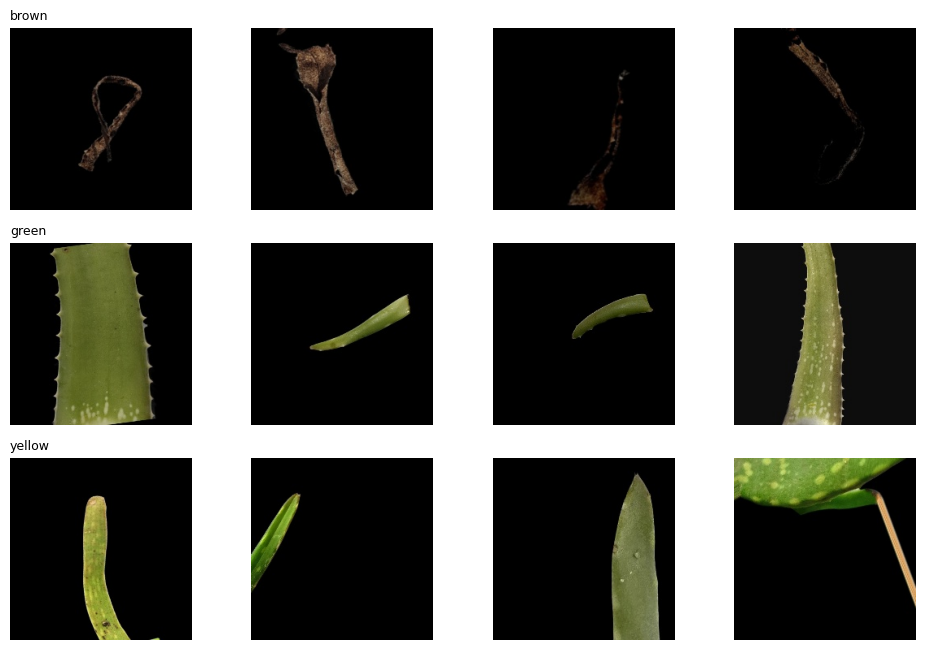

In [9]:
import matplotlib.pyplot as plt

classes = sorted(c.name for c in (OUT_DIR / "train").iterdir())
fig, axes = plt.subplots(len(classes), 4, figsize=(10, 2.2 * len(classes)), squeeze=False)
for r, c in enumerate(classes):
    pool = sorted((OUT_DIR / "train" / c).glob("aug_*.jpg")) or sorted((OUT_DIR / "train" / c).glob("*.jpg"))
    files = random.sample(pool, min(4, len(pool)))
    for k in range(4):
        ax = axes[r, k]
        ax.axis("off")
        if k < len(files):
            ax.imshow(cv2.cvtColor(cv2.imread(str(files[k])), cv2.COLOR_BGR2RGB))
        if k == 0:
            ax.set_title(c, fontsize=9, loc="left")
plt.tight_layout()
plt.show()

In [10]:
from sklearn.utils.class_weight import compute_class_weight

train_labels = []
for c in classes:
    train_labels += [c] * len(list((OUT_DIR / "train" / c).glob("*.jpg")))

weights = compute_class_weight("balanced", classes=np.array(classes), y=np.array(train_labels))
class_weight = {i: float(w) for i, w in enumerate(weights)}   # index order = alphabetical (Keras / ImageFolder order)
print(dict(zip(classes, np.round(weights, 3).tolist())))
# Any class with fewer train images gets a higher weight.
# Keras:   model.fit(..., class_weight=class_weight)
# PyTorch: nn.CrossEntropyLoss(weight=torch.tensor(weights, dtype=torch.float))

{'brown': 0.983, 'green': 1.021, 'yellow': 0.997}


In [11]:
shutil.make_archive("/kaggle/working/colour_dataset", "zip", OUT_DIR)
print("zip created: /kaggle/working/colour_dataset.zip")
# Optional: delete the loose folder to make "Save Version" faster (keep it if you train in this notebook)
# shutil.rmtree(OUT_DIR)

zip created: /kaggle/working/colour_dataset.zip


In [12]:
import os, random, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                             roc_curve, auc, precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ---------- settings ----------
DATA_ROOT = None        # leave None to find it automatically, or set e.g. Path("/kaggle/working/colour_dataset")
IMG_SIZE = 224
BATCH = 32
EPOCHS_HEAD = 8         # phase 1: train only the new top layers
EPOCHS_FINE = 20        # phase 2: fine-tune the top of MobileNetV2
SEED = 42
OUT = Path("/kaggle/working")
# ------------------------------

random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
print("TensorFlow", tf.__version__, "| GPUs:", tf.config.list_physical_devices("GPU"))

def has_splits(p):
    return all((p / s).is_dir() for s in ("train", "val", "test"))

def find_data_root():
    for base in (Path("/kaggle/working"), Path("/kaggle/input")):
        if not base.exists():
            continue
        for root, dirs, files in os.walk(base):
            if has_splits(Path(root)):
                return Path(root)
    # a zip that was not unpacked?
    for z in list(Path("/kaggle/input").rglob("colour_dataset*.zip")) + list(Path("/kaggle/working").glob("colour_dataset*.zip")):
        target = Path("/kaggle/working/colour_dataset")
        print("Unzipping", z, "->", target)
        with zipfile.ZipFile(z) as f:
            f.extractall(target)
        if has_splits(target):
            return target
    return None

if DATA_ROOT is None:
    DATA_ROOT = find_data_root()
if DATA_ROOT is None or not has_splits(Path(DATA_ROOT)):
    raise FileNotFoundError("Could not find a folder with train/val/test. Run the data-prep notebook first "
                            "or add the colour_dataset under Add Input, then set DATA_ROOT above.")
DATA_ROOT = Path(DATA_ROOT)
print("Using data:", DATA_ROOT)

# ===== load the images =====
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "train", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "val", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    label_mode="int", shuffle=False)
test_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_ROOT / "test", image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
test_files = list(test_ds.file_paths)          # keep the order, used to show wrong predictions later
print("classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds_p = test_ds.prefetch(AUTOTUNE)

# class weights from the train folder (as your sir asked)
counts = [len(list((DATA_ROOT / "train" / c).glob("*"))) for c in class_names]
labels_for_w = np.concatenate([[i] * n for i, n in enumerate(counts)])
w = compute_class_weight("balanced", classes=np.arange(NUM_CLASSES), y=labels_for_w)
class_weight = {i: float(x) for i, x in enumerate(w)}
print("train images per class:", dict(zip(class_names, counts)))
print("class weights:", {c: round(class_weight[i], 2) for i, c in enumerate(class_names)})

# ===== build the model =====
try:
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                             include_top=False, weights="imagenet")
    print("Loaded pretrained ImageNet weights.")
except Exception as e:
    print("!! Could not download pretrained weights (is Internet turned On?):", type(e).__name__)
    print("!! Continuing WITHOUT pretrained weights. Results will be much worse.")
    base = tf.keras.applications.MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                                             include_top=False, weights=None)

base.trainable = False
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.layers.RandomFlip("horizontal_and_vertical")(inputs)   # only active while training; no colour changes
x = tf.keras.layers.RandomRotation(0.07)(x)
x = tf.keras.layers.RandomZoom(0.1)(x)
x = tf.keras.layers.Rescaling(1 / 127.5, offset=-1)(x)                # MobileNetV2 expects -1..1
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
print("parameters:", f"{model.count_params():,}")

TensorFlow 2.20.0 | GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Using data: /kaggle/working/colour_dataset
Found 3778 files belonging to 3 classes.


I0000 00:00:1789968136.595308      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789968136.598212      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 916 files belonging to 3 classes.
Found 917 files belonging to 3 classes.
classes: ['brown', 'green', 'yellow']
train images per class: {'brown': 1281, 'green': 1234, 'yellow': 1263}
class weights: {'brown': 0.98, 'green': 1.02, 'yellow': 1.0}
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded pretrained ImageNet weights.
parameters: 2,261,827


In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
]

print("=== Phase 1: training the top layers ===")
h1 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD,
               class_weight=class_weight, callbacks=callbacks)

print("\n=== Phase 2: fine-tuning the top of MobileNetV2 ===")
base.trainable = True
for layer in base.layers[:-40]:                  # keep the early layers frozen
    layer.trainable = False
for layer in base.layers:                        # keep BatchNorm frozen (more stable)
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
h2 = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FINE,
               class_weight=class_weight, callbacks=callbacks)

=== Phase 1: training the top layers ===
Epoch 1/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 18s 83ms/step - accuracy: 0.8245 - loss: 0.4289 - val_accuracy: 0.9148 - val_loss: 0.2258 - learning_rate: 0.0010
Epoch 2/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9293 - loss: 0.1847 - val_accuracy: 0.9334 - val_loss: 0.1737 - learning_rate: 0.0010
Epoch 3/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9508 - loss: 0.1385 - val_accuracy: 0.9487 - val_loss: 0.1386 - learning_rate: 0.0010
Epoch 4/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.9510 - loss: 0.1258 - val_accuracy: 0.9476 - val_loss: 0.1487 - learning_rate: 0.0010
Epoch 5/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms/step - accuracy: 0.9584 - loss: 0.1127 - val_accuracy: 0.9596 - val_loss: 0.1061 - learning_rate: 0.0010
Epoch 6/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 66ms/step - accuracy: 0.9579 - loss: 0.1110 - val_accuracy: 0.9531 - val_loss: 0.1277 - learning_rate: 0.0010
Epoch 7/8
119/119 ━━━━━━━━━━━━━━━━━━━━ 8s 67ms

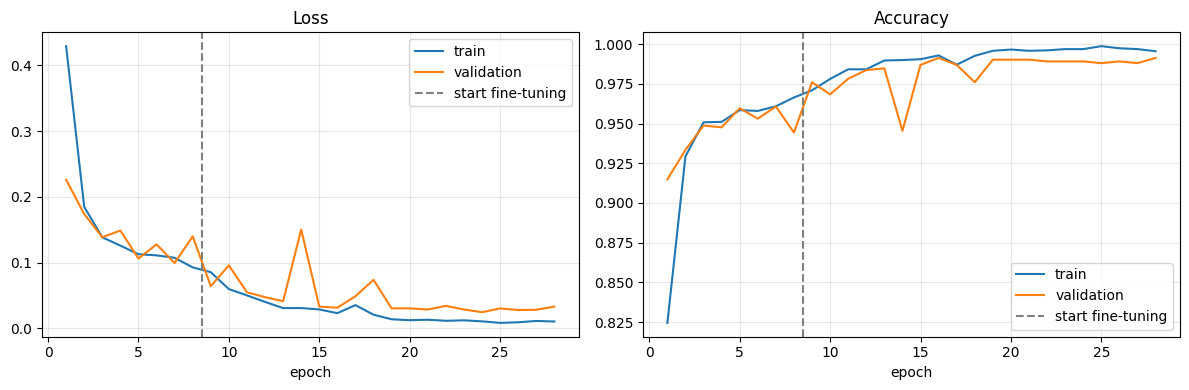

Test accuracy : 0.9935
Macro F1      : 0.9948   (the number to trust most)
Weighted F1   : 0.9935

              precision    recall  f1-score   support

       brown      1.000     1.000     1.000        50
       green      0.993     0.986     0.990       289
      yellow      0.993     0.997     0.995       578

    accuracy                          0.993       917
   macro avg      0.995     0.994     0.995       917
weighted avg      0.993     0.993     0.993       917

Test images per class: {'brown': 50, 'green': 289, 'yellow': 578}


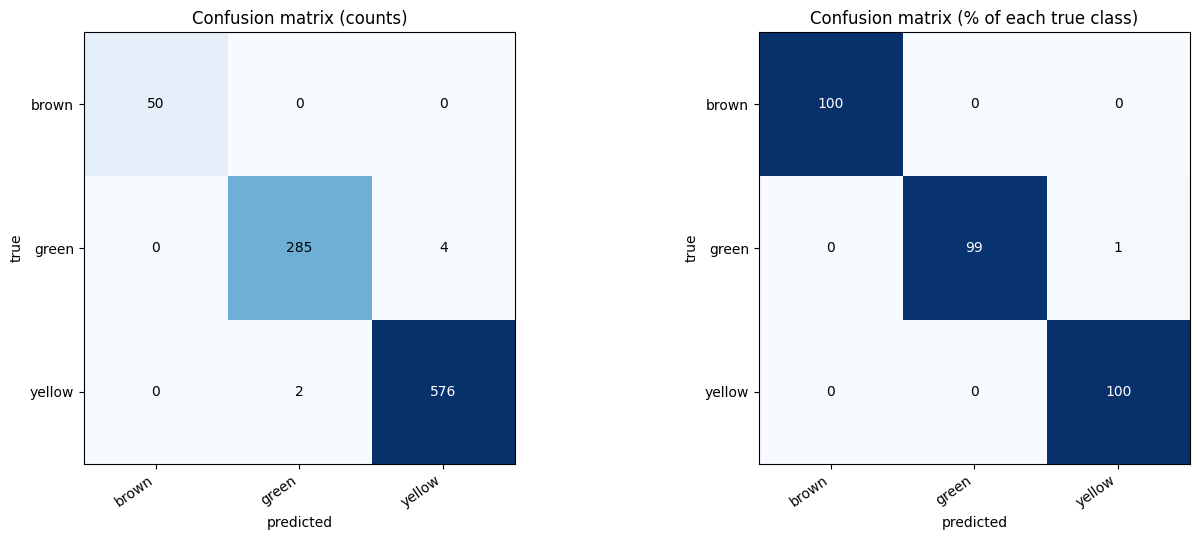

Good vs not-good accuracy: 0.9935

                         precision    recall  f1-score   support

not good (yellow/brown)      0.994     0.997     0.995       628
           good (green)      0.993     0.986     0.990       289

               accuracy                          0.993       917
              macro avg      0.993     0.991     0.992       917
           weighted avg      0.993     0.993     0.993       917

Not-good leaves predicted as GOOD: 2   <- the costlier mistake
Good leaves predicted as not good: 4


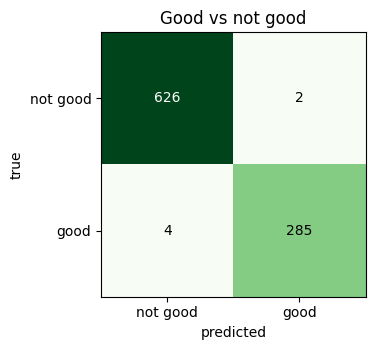

In [14]:
# ---- training curves ----
hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
split_at = len(h1.history["loss"])
epochs = range(1, len(hist["loss"]) + 1)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, key, title in [(ax[0], "loss", "Loss"), (ax[1], "accuracy", "Accuracy")]:
    a.plot(epochs, hist[key], label="train")
    a.plot(epochs, hist["val_" + key], label="validation")
    a.axvline(split_at + 0.5, color="gray", linestyle="--", label="start fine-tuning")
    a.set_title(title); a.set_xlabel("epoch"); a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- test-set predictions, F1 score and classification report ----
probs = model.predict(test_ds_p, verbose=0)
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred = probs.argmax(axis=1)

print("Test accuracy :", round((y_true == y_pred).mean(), 4))
print("Macro F1      :", round(f1_score(y_true, y_pred, average="macro"), 4), "  (the number to trust most)")
print("Weighted F1   :", round(f1_score(y_true, y_pred, average="weighted"), 4))
print()
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
print("Test images per class:", dict(zip(class_names, np.bincount(y_true, minlength=NUM_CLASSES).tolist())))

# ---- confusion matrix ----
cm = confusion_matrix(y_true, y_pred, labels=range(NUM_CLASSES))
cm_pct = cm / cm.sum(axis=1, keepdims=True).clip(min=1) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a, data, title, fmt in [(ax[0], cm, "Confusion matrix (counts)", "d"),
                            (ax[1], cm_pct, "Confusion matrix (% of each true class)", ".0f")]:
    im = a.imshow(data, cmap="Blues")
    a.set_xticks(range(NUM_CLASSES)); a.set_xticklabels(class_names, rotation=35, ha="right")
    a.set_yticks(range(NUM_CLASSES)); a.set_yticklabels(class_names)
    a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                   color="white" if data[i, j] > data.max() / 2 else "black")
plt.tight_layout(); plt.show()

# ---- good vs not good (green = good, yellow and brown = not good) ----
GOOD_CLASSES = {"green"}
good_true = np.array([class_names[i].lower() in GOOD_CLASSES for i in y_true])
good_pred = np.array([class_names[i].lower() in GOOD_CLASSES for i in y_pred])

print("Good vs not-good accuracy:", round((good_true == good_pred).mean(), 4))
print()
print(classification_report(good_true, good_pred, target_names=["not good (yellow/brown)", "good (green)"],
                            digits=3, zero_division=0))
bad_as_good = int(((~good_true) & good_pred).sum())
good_as_bad = int((good_true & (~good_pred)).sum())
print(f"Not-good leaves predicted as GOOD: {bad_as_good}   <- the costlier mistake")
print(f"Good leaves predicted as not good: {good_as_bad}")

cm2 = confusion_matrix(good_true, good_pred, labels=[False, True])
fig, a = plt.subplots(figsize=(4.2, 3.6))
a.imshow(cm2, cmap="Greens")
a.set_xticks([0, 1]); a.set_xticklabels(["not good", "good"]); a.set_yticks([0, 1]); a.set_yticklabels(["not good", "good"])
a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title("Good vs not good")
for i in range(2):
    for j in range(2):
        a.text(j, i, cm2[i, j], ha="center", va="center", color="white" if cm2[i, j] > cm2.max() / 2 else "black")
plt.tight_layout(); plt.show()

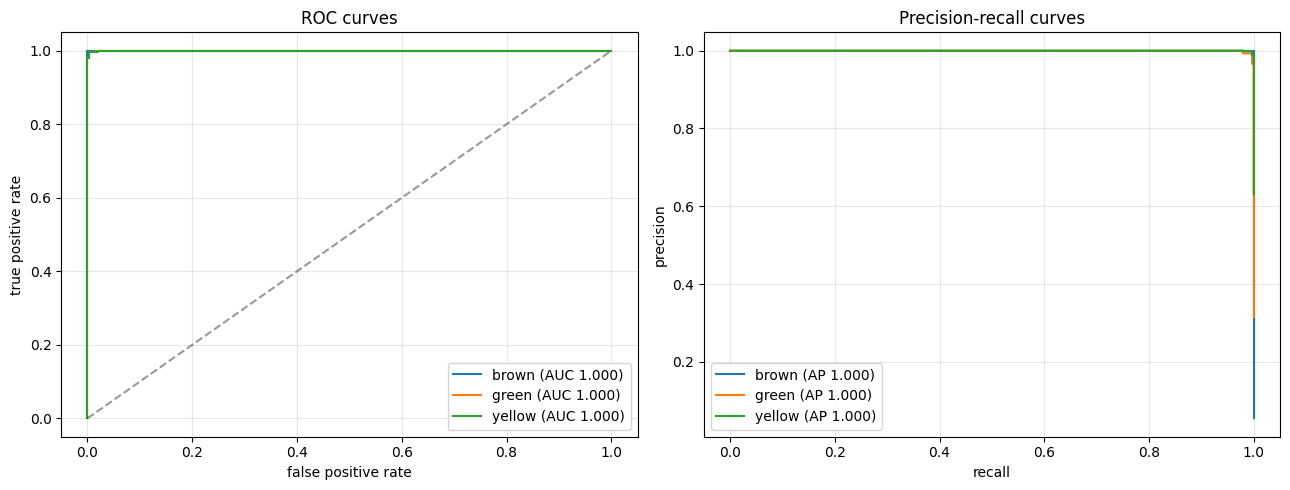

6 wrong out of 917 test images


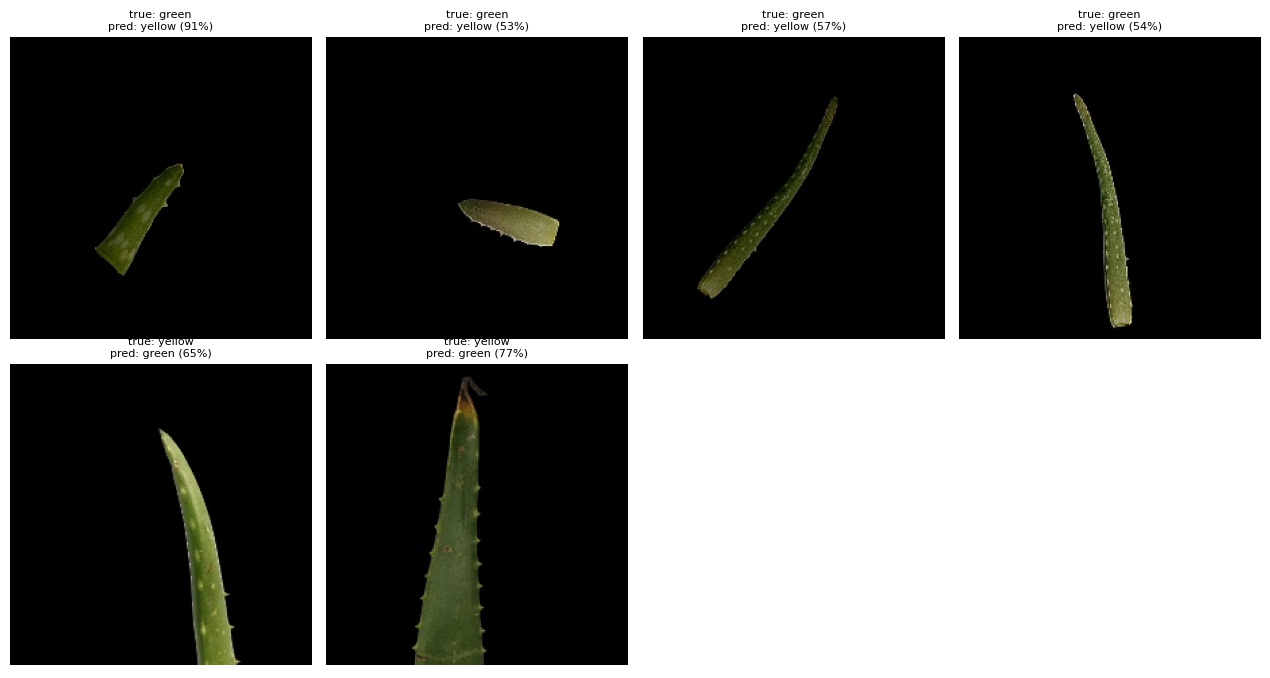

saved colour_model.keras and colour_labels.txt
label order: ['brown', 'green', 'yellow']
INFO:tensorflow:Assets written to: /tmp/tmpn8qzuhb9/assets


INFO:tensorflow:Assets written to: /tmp/tmpn8qzuhb9/assets


Saved artifact at '/tmp/tmpn8qzuhb9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  136122142930320: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142931088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142932240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142932816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142930896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142930512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142932432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122141525200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142931472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136122142927248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1361221429

W0000 00:00:1789969017.050520      58 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1789969017.050561      58 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1789969017.192447      58 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


In [15]:
# ---- ROC and precision-recall curves (one curve per class) ----
y_bin = label_binarize(y_true, classes=range(NUM_CLASSES))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, c in enumerate(class_names):
    if y_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    ax[0].plot(fpr, tpr, label=f"{c} (AUC {auc(fpr, tpr):.3f})")
    p, r, _ = precision_recall_curve(y_bin[:, i], probs[:, i])
    ax[1].plot(r, p, label=f"{c} (AP {average_precision_score(y_bin[:, i], probs[:, i]):.3f})")
ax[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
ax[0].set_title("ROC curves"); ax[0].set_xlabel("false positive rate"); ax[0].set_ylabel("true positive rate")
ax[1].set_title("Precision-recall curves"); ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision")
for a in ax:
    a.legend(loc="lower right" if a is ax[0] else "lower left"); a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---- the mistakes ----
wrong = np.where(y_true != y_pred)[0]
print(f"{len(wrong)} wrong out of {len(y_true)} test images")
show = wrong[:12]
if len(show):
    cols = 4
    rows = int(np.ceil(len(show) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.2 * cols, 3.4 * rows), squeeze=False)
    for a in axes.ravel():
        a.axis("off")
    for a, idx in zip(axes.ravel(), show):
        a.imshow(tf.keras.utils.load_img(test_files[idx], target_size=(IMG_SIZE, IMG_SIZE)))
        a.set_title(f"true: {class_names[y_true[idx]]}\npred: {class_names[y_pred[idx]]} ({probs[idx].max():.0%})", fontsize=8)
    plt.tight_layout(); plt.show()

# ---- save the model for your app ----
model.save(OUT / "colour_model.keras")
(OUT / "colour_labels.txt").write_text("\n".join(class_names))
print("saved colour_model.keras and colour_labels.txt")
print("label order:", class_names)

try:
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]      # smaller file for the phone
    tflite_model = converter.convert()
    (OUT / "colour_model.tflite").write_bytes(tflite_model)
    print(f"saved colour_model.tflite ({len(tflite_model) / 1e6:.1f} MB)")
except Exception as e:
    print("TFLite conversion failed:", type(e).__name__, str(e)[:200])

In [16]:
import os, zipfile
from IPython.display import FileLink, display

os.chdir("/kaggle/working")
files = ["colour_model.keras", "colour_model.tflite", "colour_labels.txt"]
print("missing files:", [f for f in files if not os.path.exists(f)])

with zipfile.ZipFile("colour_model_files.zip", "w") as z:
    for f in files:
        if os.path.exists(f):
            z.write(f)

display(FileLink("colour_model_files.zip"))

missing files: []


/kaggle/working/colour_model_files.zip